# 刘嘉硕 2213645 回归上机作业2

In [1]:
library(readxl)
data <- read_excel('C:/Users/lenovo/Screen/TD/3-15.xlsx')
head(data)

用户,X,Y
<dbl>,<dbl>,<dbl>
1,679,0.79
2,292,0.44
3,1012,0.56
4,493,0.79
5,582,2.70
6,1156,3.64


## （1）应用最小二乘法求经验回归方程

In [2]:
model <- lm(Y ~ X, data = data)
summary(model)


Call:
lm(formula = Y ~ X, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.0911 -0.8147 -0.1965  1.2446  3.2006 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.7880079  0.4499583  -1.751   0.0859 .  
X            0.0036186  0.0003376  10.719 1.15e-14 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.609 on 51 degrees of freedom
Multiple R-squared:  0.6926,	Adjusted R-squared:  0.6866 
F-statistic: 114.9 on 1 and 51 DF,  p-value: 1.146e-14


In [3]:
a <- coef(model)[1]
b <- coef(model)[2]
regression_equation <- paste("y =", round(a, 4), " +", round(b, 4), "x")
cat('用最小二乘法得到的经验回归方程为：',regression_equation)

用最小二乘法得到的经验回归方程为： y = -0.788  + 0.0036 x

## （2）制作残差图, 分析Gauss-Markov假设对本例的适用性

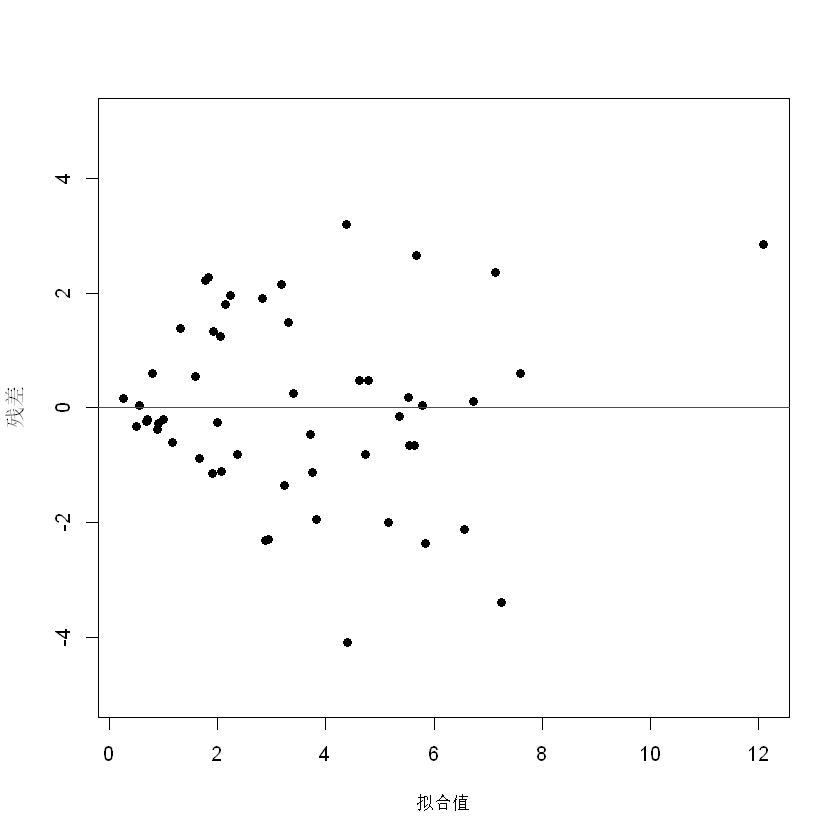

In [4]:
library(ggplot2)
plot(fitted(model), residuals(model), xlab = "拟合值", ylab = "残差",ylim = c(-5,5), pch = 19)
abline(h = 0, col = "red")

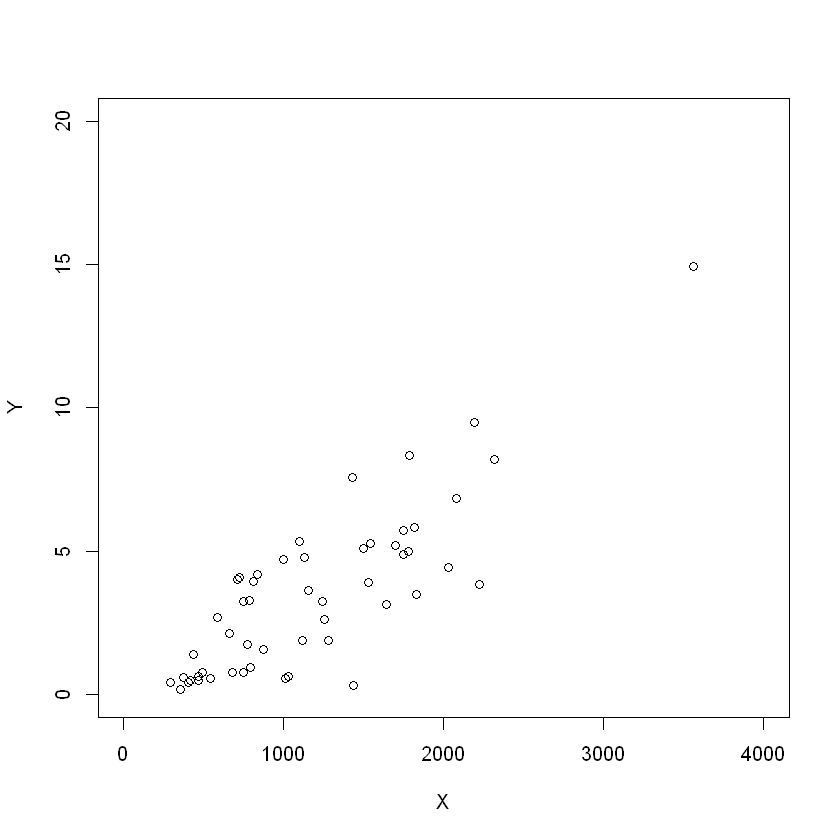

In [5]:
plot(data$X, data$Y, xlim = c(0,4000), ylim = c(0,20),xlab = "X", ylab = "Y") 

从残差图中看出，残差呈现绝对值增大的趋势，所以Gauss-Markov假设对本例不适用

## (3)构造新变量U, 对U和X重复(1)和(2)

In [6]:
U <- data$Y**(1/2)
data$U <- U
head(data)

用户,X,Y,U
<dbl>,<dbl>,<dbl>,<dbl>
1,679,0.79,0.8888194
2,292,0.44,0.6633250
3,1012,0.56,0.7483315
4,493,0.79,0.8888194
5,582,2.70,1.6431677
6,1156,3.64,1.9078784


In [7]:
model1 <- lm(U ~ X, data = data)
a1 = coef(model1)[1]
b1 = coef(model1)[2]
regression_equation1 <- paste("u =", round(a1, 5), " +", round(b1, 5), "x")
cat('用最小二乘法得到的经验回归方程为：',regression_equation1)

用最小二乘法得到的经验回归方程为： u = 0.58957  + 0.00094 x

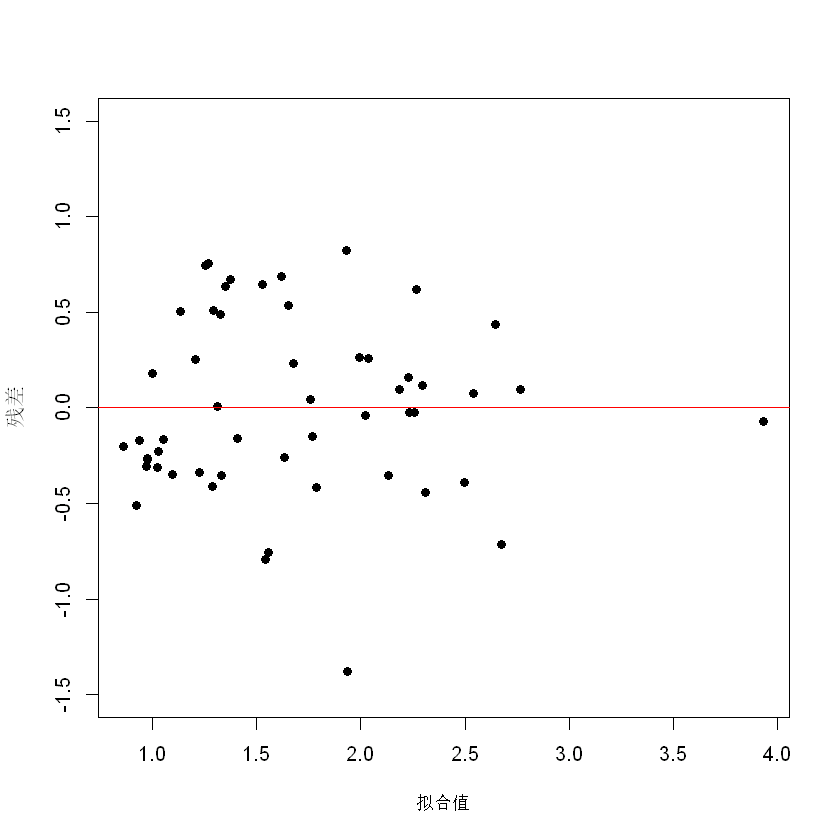

In [8]:
plot(fitted(model1), residuals(model1), xlab = "拟合值", ylab = "残差", pch = 19, ylim = c(-1.5, 1.5) )
abline( h =0, col = "red") 

根据残差图，残差随机分布在y=0这条直线两侧，适用Gauss-Markov假设

## (4)做Box-Cox变换, 计算变换参数λ的值

λ取值为： 0.5454545

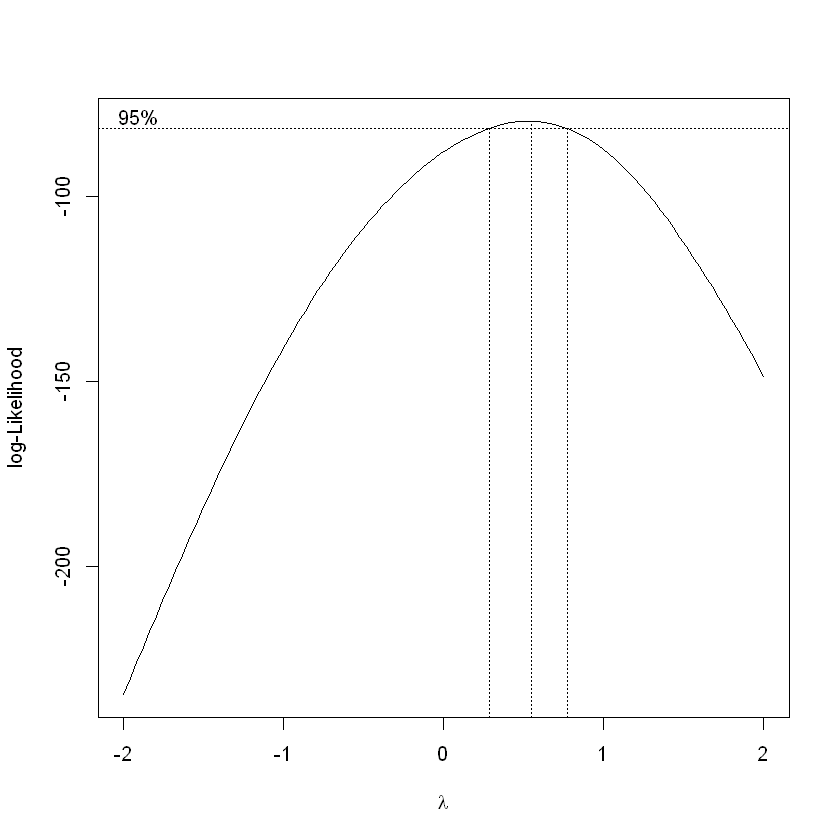

In [9]:
library(MASS)
lambda_result <- boxcox(model, lambda = seq(-2, 2, length = 100))
lambda_best <- lambda_result$x[which.max(lambda_result$y)]
cat('λ取值为：',lambda_best)

In [10]:
data$V <- (data$Y^lambda_best - 1) / lambda_best
head(data)

用户,X,Y,U,V
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,679,0.79,0.8888194,-0.2211974
2,292,0.44,0.6633250,-0.6617827
3,1012,0.56,0.7483315,-0.4970780
4,493,0.79,0.8888194,-0.2211974
5,582,2.70,1.6431677,1.3182643
6,1156,3.64,1.9078784,1.8760075


用最小二乘法得到的经验回归方程为： v = -0.86925  + 0.00198 x

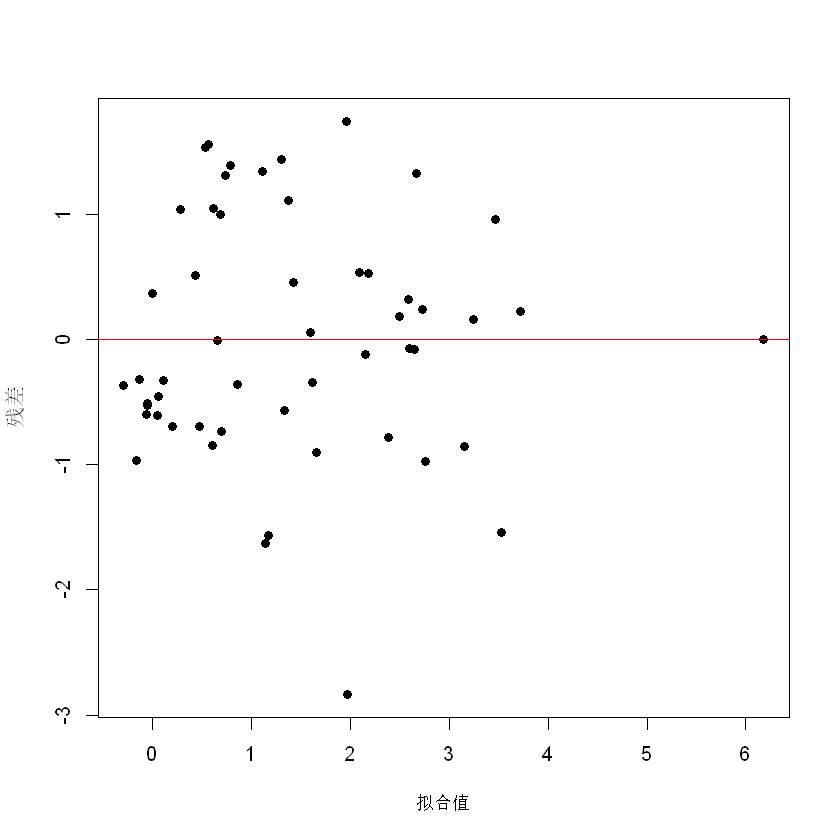

In [11]:
model2 <- lm(V ~ X, data = data)
a2 = coef(model2)[1]
b2 = coef(model2)[2]
regression_equation2 <- paste("v =", round(a2, 5), " +", round(b2, 5), "x")
cat('用最小二乘法得到的经验回归方程为：',regression_equation2)
plot(fitted(model2), residuals(model2), xlab = "拟合值", ylab = "残差", pch = 19)
abline( h =0, col = "red") 

## (5)做影响分析,找出强影响点

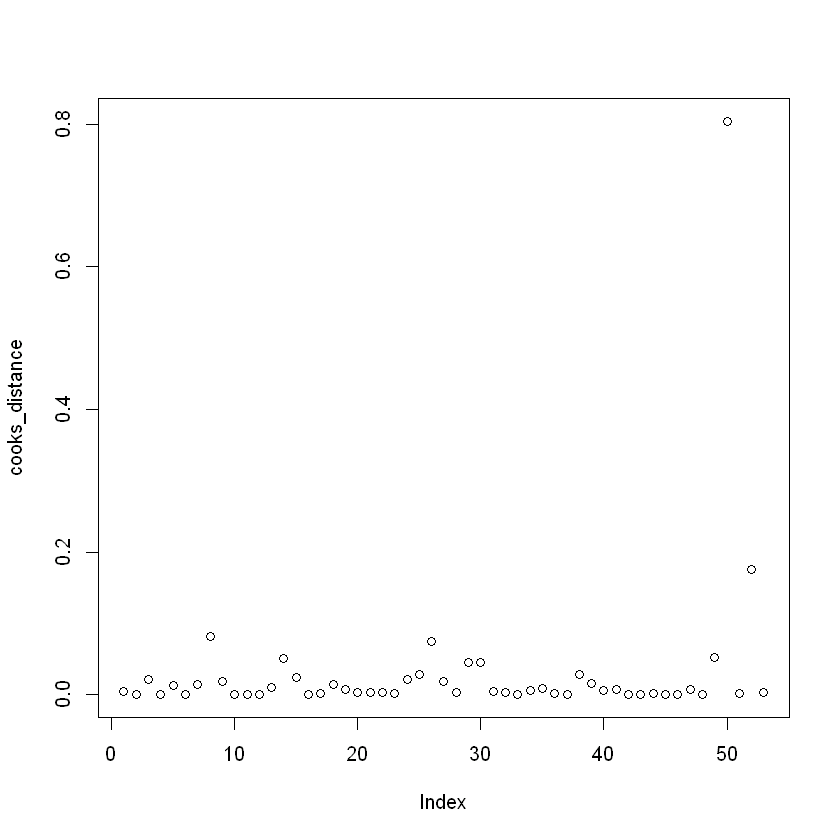

In [12]:
cooks_distance <- cooks.distance(model)
plot(cooks_distance)

通过分析Cook`s图像

In [13]:
sorted_indices <- order(cooks_distance, decreasing = TRUE)
high_cooks_distance <- sorted_indices[1:2]
cat('强影响点为：',high_cooks_distance)

强影响点为： 50 52

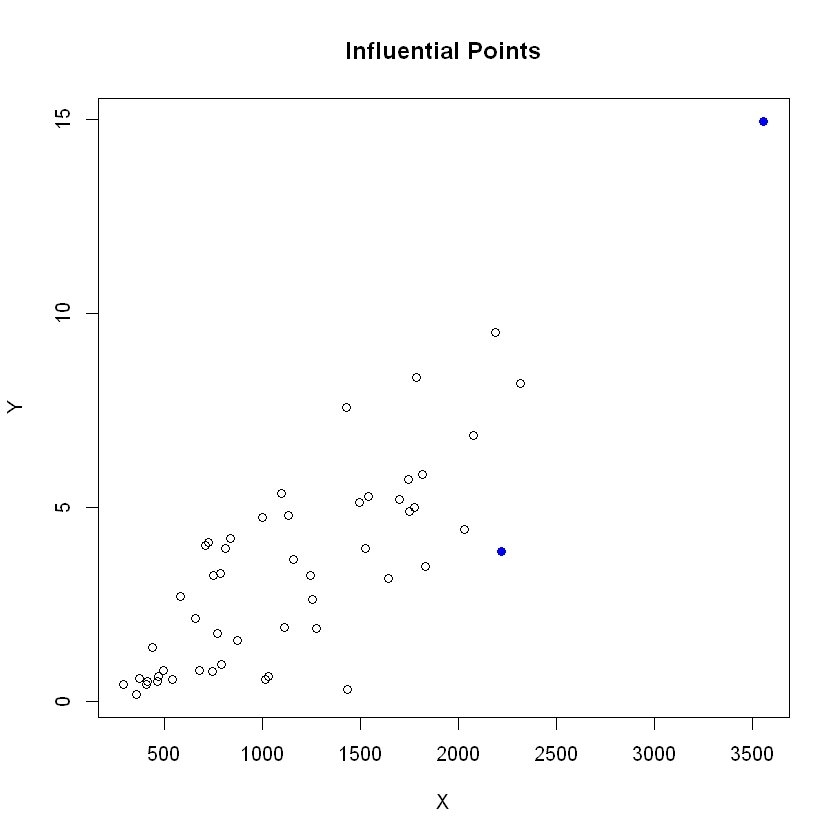

In [14]:
# 绘制散点图,标记高Cook's距离的强影响点
plot(data$X, data$Y, xlab = "X", ylab = "Y", main = "Influential Points")
points(data$X[high_cooks_distance], data$Y[high_cooks_distance], col = "blue", pch = 19)